# Fall & Call: Emergency Keyword Spotting (KWS) v2.0
This notebook trains a CNN model to recognize **"HELP"**, **"EMERGENCY"**, **"CANCEL"** and **"BACKGROUND NOISE"**.

It follows the standard TinyML workflow used in the gender classification project, ensuring compatibility with the Nano 33 BLE Sense audio capture.

### **Model Update**: This version uses `SeparableConv2D` for improved parameter efficiency on microcontrollers.

In [ ]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D, Conv2D, Flatten
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import os
import shutil
import json

# Set MFCC parameters (Matching Lab 4 / Nano 33 BLE Sense specs)
N_MFCC = 13 
N_MELS = 26
SAMPLING_RATE = 16000 # 16 kHz
FRAME_SIZE = 512 # 32 ms
HOP_LENGTH = 256 # 16 ms
MIN_FREQ = 50
MAX_FREQ = SAMPLING_RATE / 2

# 1 second of audio at 16kHz = 16000 samples
# With center=False, n_frames = (16000 - 512) // 256 + 1 = 61
N_FRAMES = 61

# Precise length required for MFCC frames
TARGET_LENGTH = FRAME_SIZE + (N_FRAMES - 1) * HOP_LENGTH 
CLASSES = ['help', 'cancel', 'background']

print(f"Target Samples per Clip: {TARGET_LENGTH}")

c:\Jon\Uni stuff\CE\Embedded-Systems\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Target Samples per Clip: 15872


**1. Load and preprocess the data**

In [ ]:
def normalize_audio(audio):
    max_val = np.max(np.abs(audio))
    return audio / max_val if max_val > 0 else audio

def extract_mfcc(data):
    return librosa.feature.mfcc(
        y=data, sr=SAMPLING_RATE, n_mfcc=N_MFCC, n_mels=N_MELS,
        n_fft=FRAME_SIZE, hop_length=HOP_LENGTH, fmin=MIN_FREQ, fmax=MAX_FREQ,
        window='hann', center=False, dct_type=2, norm='ortho', power=2
    )

def process_csv_file(filename, label):
    print(f"Processing {filename}...")
    df = pd.read_csv(filename, header=None, on_bad_lines='skip')
    df = df.apply(pd.to_numeric, errors='coerce')
    raw_samples = df.dropna().values.flatten()
    
    mfccs, labels = [], []
    
    # Chunking with Padding (The Optimal Logic)
    num_full_snippets = len(raw_samples) // TARGET_LENGTH
    for i in range(num_full_snippets):
        snippet = raw_samples[i*TARGET_LENGTH : (i+1)*TARGET_LENGTH]
        mfcc = extract_mfcc(normalize_audio(snippet))
        mfccs.append(mfcc)
        labels.append(label)
        
    # Handle the remainder
    remainder = len(raw_samples) % TARGET_LENGTH
    if remainder > (TARGET_LENGTH // 2): # Only pad if remainder is significant
        snippet = raw_samples[-remainder:]
        pad_size = TARGET_LENGTH - remainder
        snippet = np.pad(snippet, (pad_size // 2, pad_size - (pad_size // 2)))
        mfcc = extract_mfcc(normalize_audio(snippet))
        mfccs.append(mfcc)
        labels.append(label)
        
    return np.array(mfccs), np.array(labels)

# --- Execution & Mel Filter Bank Export ---
all_x, all_y = [], []
for cls in CLASSES:
    x, y = process_csv_file(f"audio_{cls}.csv", cls)
    all_x.append(x)
    all_y.append(y)

X = np.vstack(all_x)
y = np.concatenate(all_y)

# Export Mel Filter Bank for Arduino Parity
mel_fb = librosa.filters.mel(sr=SAMPLING_RATE, n_fft=FRAME_SIZE, n_mels=N_MELS, fmin=MIN_FREQ, fmax=MAX_FREQ)
with open("mel_filter_bank.h", "w") as f:
    f.write("const float mel_filter_bank[26][257] = {\n")
    for row in mel_fb:
        f.write("  {" + ", ".join([f"{val}f" for val in row]) + "},\n")
    f.write("};")

# Split Data
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = X[..., np.newaxis] # Add channel dimension (13, 61, 1)

x_train, x_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.4, stratify=y_encoded, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

Processing audio_help.csv...
Processing audio_cancel.csv...
Processing audio_background.csv...


**3. Training the Model**

In [4]:
# -------------------------------
# 1. Reset model
# -------------------------------
tf.keras.backend.clear_session()

# -------------------------------
# 2. Reshape input for CNN
# -------------------------------
# In Audio: 
# Height = N_MFCC (Frequency bins)
# Width = N_FRAMES (Time steps)
train_mfccs_cnn = x_train.reshape(-1, N_MFCC, N_FRAMES, 1)
val_mfccs_cnn   = x_val.reshape(-1, N_MFCC, N_FRAMES, 1)
test_mfccs_cnn  = x_test.reshape(-1, N_MFCC, N_FRAMES, 1)

# -------------------------------
# 3. Build CNN model
# -------------------------------
model = tf.keras.models.Sequential([
    # Input shape: (13, 61, 1)
    tf.keras.layers.Input(shape=(N_MFCC, N_FRAMES, 1)),

    # Layer 1: Kernel (3, N_MFCC) 
    # Added padding='same' to prevent dimension collapse
    tf.keras.layers.SeparableConv2D(16, kernel_size=(3, N_MFCC), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)), # Standard 2x2 pool

    # Layer 2: Temporal filtering
    tf.keras.layers.SeparableConv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Layer 3: Temporal filtering
    tf.keras.layers.SeparableConv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

# -------------------------------
# 4. Compile
# -------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 5. Early stopping
# -------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# -------------------------------
# 6. Train
# -------------------------------
history = model.fit(
    train_mfccs_cnn, y_train,
    validation_data=(val_mfccs_cnn, y_val),
    epochs=200,
    batch_size=12,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------
# 7. Evaluate
# -------------------------------
actual_epochs = len(history.history['loss'])
print("Epochs actually run:", actual_epochs)
test_loss, test_acc = model.evaluate(test_mfccs_cnn, y_test)
print("\nTest Accuracy:", test_acc)


Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3536 - loss: 1.1129 - val_accuracy: 0.3443 - val_loss: 1.0686
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3149 - loss: 1.0534 - val_accuracy: 0.3607 - val_loss: 1.0401
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4641 - loss: 1.0119 - val_accuracy: 0.5902 - val_loss: 1.0065
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4641 - loss: 0.9812 - val_accuracy: 0.7049 - val_loss: 0.9696
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5967 - loss: 0.9695 - val_accuracy: 0.5246 - val_loss: 0.9579
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6022 - loss: 0.8886 - val_accuracy: 0.6393 - val_loss: 0.9209
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6464 - loss: 0.8383 - val_accuracy: 0.5410 - val_loss: 0.8787
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7403 - loss: 0.8041 - val_accuracy: 0.4918 -

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 13, 61, 16)     │            71 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 30, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 6, 30, 32)      │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 15, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 3, 15, 64)      │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,016 (62.57 KB)

 Trainable params: 5,338 (20.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,678 (41.71 KB)

**4. Evaluating the Model**

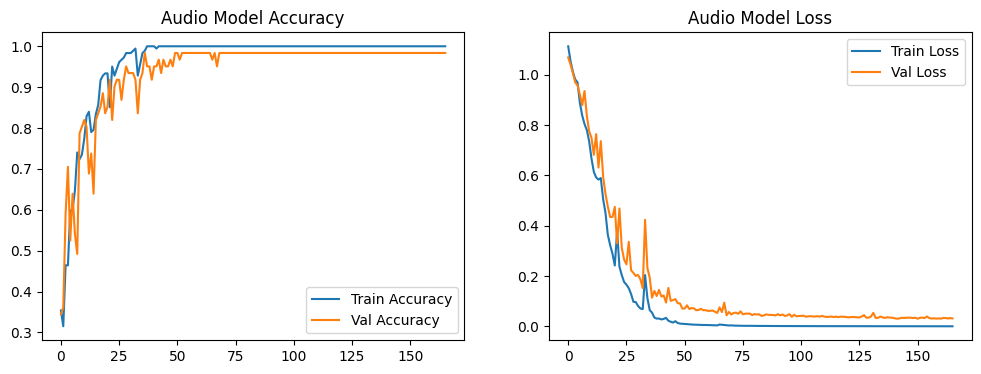

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy Plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Audio Model Accuracy')
ax[0].legend()

# Loss Plot
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Audio Model Loss')
ax[1].legend()
plt.show()

**5. Confusion Matrix**

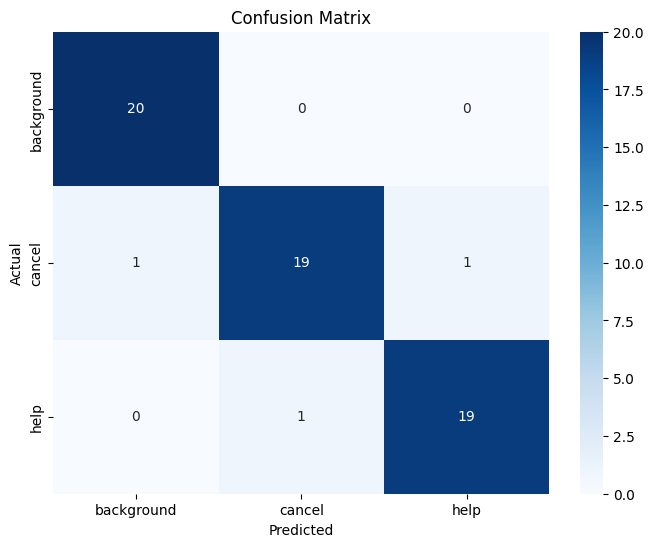

              precision    recall  f1-score   support

  background       0.95      1.00      0.98        20
      cancel       0.95      0.90      0.93        21
        help       0.95      0.95      0.95        20

    accuracy                           0.95        61
   macro avg       0.95      0.95      0.95        61
weighted avg       0.95      0.95      0.95        61



In [ ]:
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_)
      )

**6. Conversion to TFLite**

In [14]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]
tflite_model = converter.convert()

# Save the model to disk
with open("emergency_model.tflite", "wb") as f:
    f.write(tflite_model)

import os
basic_model_size = os.path.getsize("emergency_model.tflite")
print("Model is %d bytes" % basic_model_size)

print("Model converted to TFLite format!")

INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmph20w7ddf\assets
Model is 27064 bytes
Model converted to TFLite format!


In [15]:
emergencyModel = open("emergency_model.tflite", "rb").read()
interpreter = tf.lite.Interpreter(model_content=emergencyModel)
interpreter.allocate_tensors()

print(interpreter.get_input_details())


[{'name': 'input_1', 'index': 0, 'shape': array([ 1, 13, 61,  1]), 'shape_signature': array([-1, 13, 61,  1]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
